**Simple Linear Regression**

It is assumed that the two variables are linearly related. Hence, we try to find a linear function that predicts the response value(y) as accurately as possible as a function of the feature or independent variable(x).
Let us consider a dataset where we have a value of response y for every feature x:

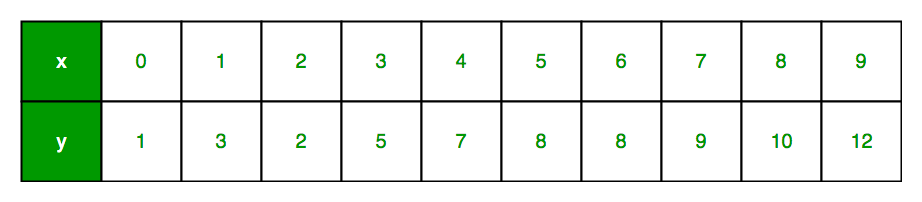

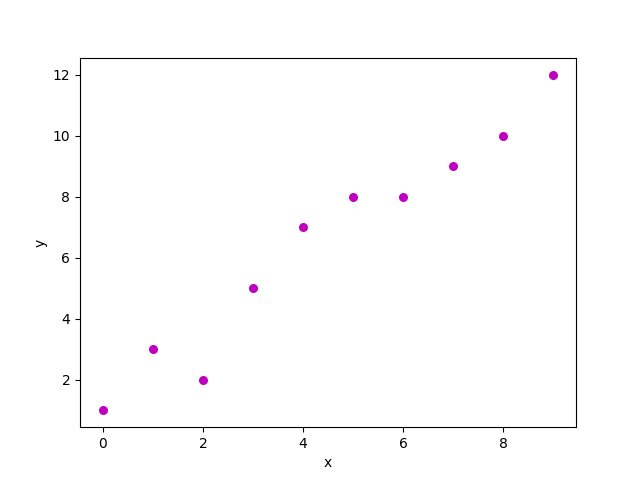

Now, the task is to find a line that fits best in the above scatter plot so that we can predict the response for any new feature values. (i.e a value of x not present in a dataset)
This line is called a regression line.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def estimate_coef(x, y):
    # number of observations/points
    n = np.size(x)

    # mean of x and y vector
    m_x = np.mean(x)
    m_y = np.mean(y)

    # calculating cross-deviation and deviation about x
    SS_xy = np.sum(y*x) - n*m_y*m_x
    SS_xx = np.sum(x*x) - n*m_x*m_x

    # calculating regression coefficients
    b_1 = SS_xy / SS_xx
    b_0 = m_y - b_1*m_x

    return (b_0, b_1)

def plot_regression_line(x, y, b):
    # plotting the actual points as scatter plot
    plt.scatter(x, y, color = "m",
               marker = "o", s = 30)

    # predicted response vector
    y_pred = b[0] + b[1]*x

    # plotting the regression line
    plt.plot(x, y_pred, color = "g")

    # putting labels
    plt.xlabel('x')
    plt.ylabel('y')

    # function to show plot
    plt.show()
def main():
    # observations / data
    x = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
    y = np.array([1, 3, 2, 5, 7, 8, 8, 9, 10, 12])

    # estimating coefficients
    b = estimate_coef(x, y)
    print("Estimated coefficients:\nb_0 = {}  \
          \nb_1 = {}".format(b[0], b[1]))

    # plotting regression line
    plot_regression_line(x, y, b)

if __name__ == "__main__":
    main()

**Multiple linear regression**

Multiple linear regression attempts to model the relationship between two or more features and a response by fitting a linear equation to the observed data.
Clearly, it is nothing but an extension of simple linear regression.
Consider a dataset with p features(or independent variables) and one response(or dependent variable).
Also, the dataset contains n rows/observations.
We define:
X (feature matrix) = a matrix of size n X p where x_{ij} denotes the values of jth feature for ith observation.

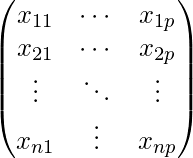

y (response vector) = a vector of size n where y_{i} denotes the value of response for ith observation.

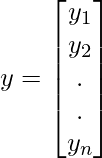

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets, linear_model, metrics

# load the boston dataset
boston = datasets.load_boston(return_X_y=False)

# defining feature matrix(X) and response vector(y)
X = boston.data
y = boston.target

# splitting X and y into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4,
                                                    random_state=1)

# create linear regression object
reg = linear_model.LinearRegression()

# train the model using the training sets
reg.fit(X_train, y_train)

# regression coefficients
print('Coefficients: ', reg.coef_)

# variance score: 1 means perfect prediction
print('Variance score: {}'.format(reg.score(X_test, y_test)))

# plot for residual error

## setting plot style
plt.style.use('fivethirtyeight')

## plotting residual errors in training data
plt.scatter(reg.predict(X_train), reg.predict(X_train) - y_train,
            color = "green", s = 10, label = 'Train data')

## plotting residual errors in test data
plt.scatter(reg.predict(X_test), reg.predict(X_test) - y_test,
            color = "blue", s = 10, label = 'Test data')

## plotting line for zero residual error
plt.hlines(y = 0, xmin = 0, xmax = 50, linewidth = 2)

## plotting legend
plt.legend(loc = 'upper right')

## plot title
plt.title("Residual errors")

## method call for showing the plot
plt.show()

**Hypothesis function for Linear Regression :**

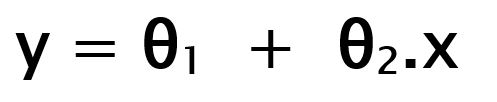

θ1: intercept

θ2: coefficient of x

Once we find the best θ1 and θ2 values, we get the best fit line. So when we are finally using our model for prediction, it will predict the value of y for the input value of x.

**Normal Equation in Linear Regression**

Normal Equation is an analytical approach to Linear Regression with a Least Square Cost Function. We can directly find out the value of θ without using Gradient Descent. Following this approach is an effective and time-saving option when are working with a dataset with small features.

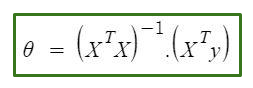

In the above equation,
θ: hypothesis parameters that define it the best.
X: Input feature value of each instance.
Y: Output value of each instance.

Example:


In [ ]:
# import required modules
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

# Create data set.
x,y=make_regression(n_samples=100,n_features=1,n_informative=1,noise = 10,random_state=10)

# Plot the generated data set.
plt.scatter(x,y,s=30,marker='o')
plt.xlabel("Feature_1 --->")
plt.ylabel("Target_Variable --->")
plt.title('Simple Linear Regression')
plt.show()

# Convert  target variable array from 1d to 2d.
y=y.reshape(100,1)

**Normal Equation implementation:**

In [ ]:
# Adding x0=1 to each instance
x_new=np.array([np.ones(len(x)),x.flatten()]).T

# Using Normal Equation.
theta_best_values=np.linalg.inv(x_new.T.dot(x_new)).dot(x_new.T).dot(y)

# Display best values obtained.
print(theta_best_values)

 predict for new data instance:

In [ ]:
# sample data instance.
x_sample=np.array([[-2],[4]])

# Adding x0=1 to each instance.
x_sample_new=np.array([np.ones(len(x_sample)),x_sample.flatten()]).T

# Display the sample.
print("Before adding x0:\n",x_sample)
print("After adding x0:\n",x_sample_new)

In [ ]:
# predict the values for given data instance.
predict_value=x_sample_new.dot(theta_best_values)
print(predict_value)

Plot the output:

In [ ]:
# Plot the output.
plt.scatter(x,y,s=30,marker='o')
plt.plot(x_sample,predict_value,c='red')
plt.plot()
plt.xlabel("Feature_1 --->")
plt.ylabel("Target_Variable --->")
plt.title('Simple Linear Regression')
plt.show()

Verify the above using sklearn LinearRegression class:

In [ ]:
# Verification.
from sklearn.linear_model import LinearRegression
lr=LinearRegression()    # Object.
lr.fit(x,y)              # fit method.

# Print obtained theta values.
print("Best value of theta:",lr.intercept_,lr.coef_,sep='\n')

#predict.
print("predicted value:",lr.predict(x_sample),sep='\n')

**Gradient Descent in Linear Regression**

In [ ]:
# Implementation of gradient descent in linear regression
import numpy as np
import matplotlib.pyplot as plt

class Linear_Regression:
	def __init__(self, X, Y):
		self.X = X
		self.Y = Y
		self.b = [0, 0]

	def update_coeffs(self, learning_rate):
		Y_pred = self.predict()
		Y = self.Y
		m = len(Y)
		self.b[0] = self.b[0] - (learning_rate * ((1/m) *
								np.sum(Y_pred - Y)))

		self.b[1] = self.b[1] - (learning_rate * ((1/m) *
								np.sum((Y_pred - Y) * self.X)))

	def predict(self, X=[]):
		Y_pred = np.array([])
		if not X: X = self.X
		b = self.b
		for x in X:
			Y_pred = np.append(Y_pred, b[0] + (b[1] * x))

		return Y_pred

	def get_current_accuracy(self, Y_pred):
		p, e = Y_pred, self.Y
		n = len(Y_pred)
		return 1-sum(
			[
				abs(p[i]-e[i])/e[i]
				for i in range(n)
				if e[i] != 0]
		)/n
	#def predict(self, b, yi):

	def compute_cost(self, Y_pred):
		m = len(self.Y)
		J = (1 / 2*m) * (np.sum(Y_pred - self.Y)**2)
		return J

	def plot_best_fit(self, Y_pred, fig):
				f = plt.figure(fig)
				plt.scatter(self.X, self.Y, color='b')
				plt.plot(self.X, Y_pred, color='g')
				f.show()


def main():
	X = np.array([i for i in range(11)])
	Y = np.array([2*i for i in range(11)])

	regressor = Linear_Regression(X, Y)

	iterations = 0
	steps = 100
	learning_rate = 0.01
	costs = []

	#original best-fit line
	Y_pred = regressor.predict()
	regressor.plot_best_fit(Y_pred, 'Initial Best Fit Line')


	while 1:
		Y_pred = regressor.predict()
		cost = regressor.compute_cost(Y_pred)
		costs.append(cost)
		regressor.update_coeffs(learning_rate)

		iterations += 1
		if iterations % steps == 0:
			print(iterations, "epochs elapsed")
			print("Current accuracy is :",
				regressor.get_current_accuracy(Y_pred))

			stop = input("Do you want to stop (y/*)??")
			if stop == "y":
				break

	#final best-fit line
	regressor.plot_best_fit(Y_pred, 'Final Best Fit Line')

	#plot to verify cost function decreases
	h = plt.figure('Verification')
	plt.plot(range(iterations), costs, color='b')
	h.show()

	# if user wants to predict using the regressor:
	regressor.predict([i for i in range(10)])

if __name__ == '__main__':
	main()
